# **RAG 구축하기_벡터DB 구성과 RAG 파이프라인 구축1 : 기본 절차 익히기**

## **1.환경준비**

### (1) 구글 드라이브

#### 1) 구글 드라이브 폴더 생성
* 새 폴더(langchain)를 생성하고
* 제공 받은 파일을 업로드

#### 2) 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (2) 라이브러리

#### 1) 필요한 라이브러리 설치

In [ ]:
!pip install langchain langchain-community langchain-openai chromadb tiktoken -q

#### 2) 라이브러리 로딩

In [ ]:
import pandas as pd
import numpy as np
import os
import openai

from langchain.document_loaders import PyMuPDFLoader
from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import Chroma
from langchain.chains import RetrievalQA
from langchain_openai import ChatOpenAI
from langchain.schema import HumanMessage, SystemMessage, AIMessage
from langchain.chains import ConversationalRetrievalChain
from langchain.memory import ConversationBufferMemory

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

### (3) OpenAI API Key 등록
* 환경변수로 key 등록

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/langchain/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

* ⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [ ]:
print(os.environ['OPENAI_API_KEY'][:40])

## 2.Vector DB 구성

**Vector DB**
- 대규모 텍스트 데이터 및 임베딩 벡터를 저장, 검색용

**Vector DB 구축 절차**
- 텍스트 추출 : Loader
    - 다양한 문서(word, pdf, web page 등)로 부터 텍스트 추출하기
- 텍스트 분할 : Splitter
    - chunk 단위로 분할
    - Document 객체로 만들기
- 텍스트 벡터화 : Text Embedding
- Vector DB로 저장 : Vector Store


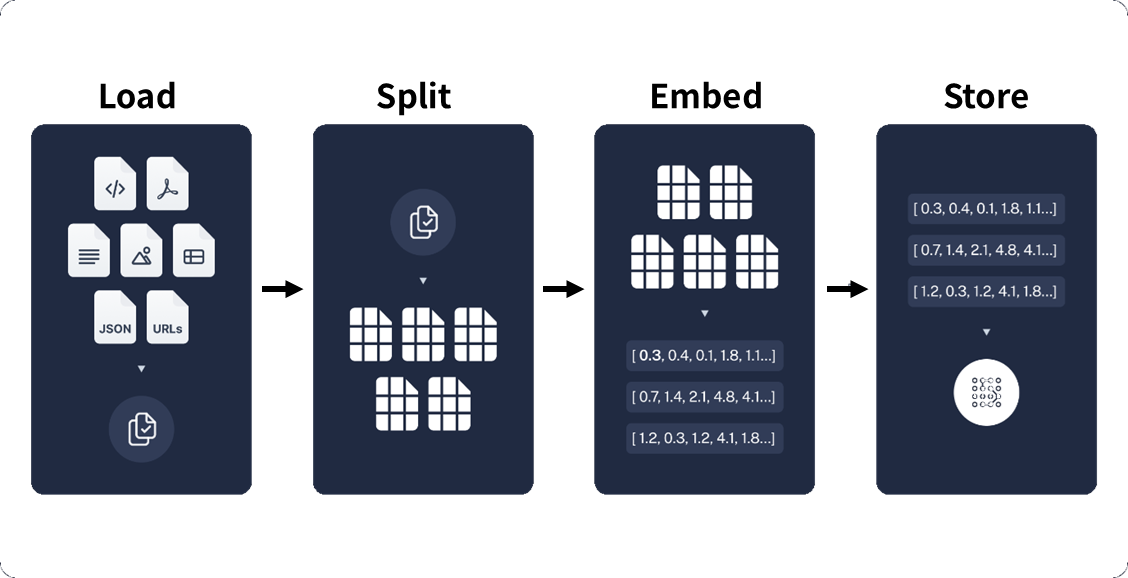


### (1) Loader

- 다양한 소스에서 문서를 불러오고 처리하는 과정을 담당
    - 사전지식이 필요한 지식 기반의 태스크, 정보 검색, 데이터 처리 작업 등을 처리할 때 반드시 필요
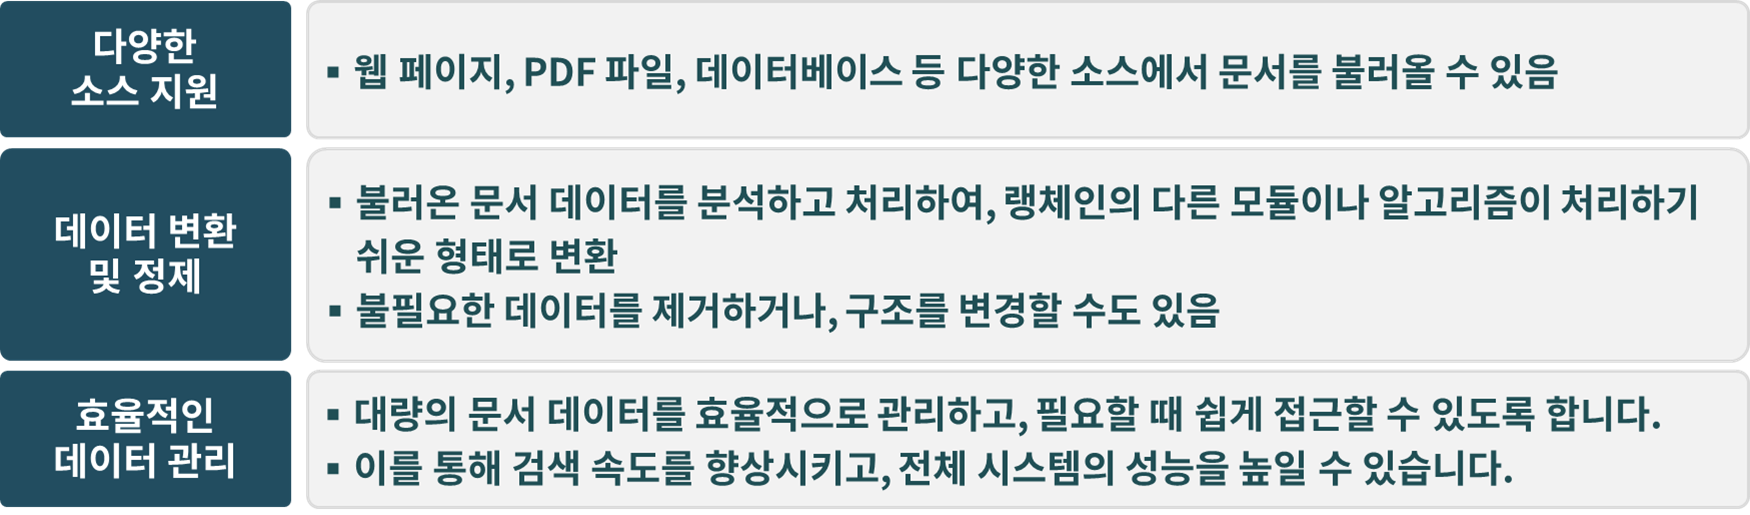

#### 1) TextLoader

- LangChain에서 가장 기본적인 데이터 로더 중 하나
- 일반적인 텍스트 파일(.txt)에서 데이터를 불러오는 역할
- txt 파일을 읽고, 이를 LangChain에서 사용할 수 있는 문서 객체(Document)로 변환


In [ ]:
from langchain.document_loaders import TextLoader

# 텍스트 파일 경로 지정
file_path = "상록수.txt"

# TextLoader를 이용하여 문서 로드
loader = TextLoader(path+file_path)
documents = loader.load()

# 로드된 문서 출력
print(documents)

* 로딩된 데이터의 타입과 길이를 살펴 봅시다.

In [ ]:
print(type(documents))
print(len(documents))
print(type(documents[0]))

In [ ]:
documents[0].page_content[:1000]

#### 2) Document

- LangChain에서 텍스트 데이터(문서)를 구조적으로 표현하는 기본 단위
- 주요 속성
    - metadata : 문서의 출처, 태그, 카테고리 등의 부가 정보
    - page_content : 문서의 실제 텍스트 내용
- Loader로 로딩한 후 저장하거나, 직접 Document 생성 가능


In [ ]:
from langchain.schema import Document

doc = Document(
    page_content="이것은 LangChain의 Document 객체 예제입니다.",
    metadata={"source": "sample.txt", "category": "example"}
)
doc

In [ ]:
doc.metadata

In [ ]:
doc.page_content

In [ ]:
text = documents[0].page_content
text

### (2) Splitter

- 긴 문서를 작은 단위인 청크(chunk)로 나누는 텍스트 분리 도구
    - 텍스트를 분리하는 작업 : 청킹(chunking)
        - LLM 모델의 입력 토큰의 개수가 정해져 있기 때문
        - 텍스트가 너무 긴 경우에는 핵심 정보 이외에 불필요한 정보들이 많이 포함  RAG 품질 저하 요인
        - 핵심 정보가 유지될 수 있는 적절한 크기로 나누는 것이 매우 중요
        
**분할시 고려사항**
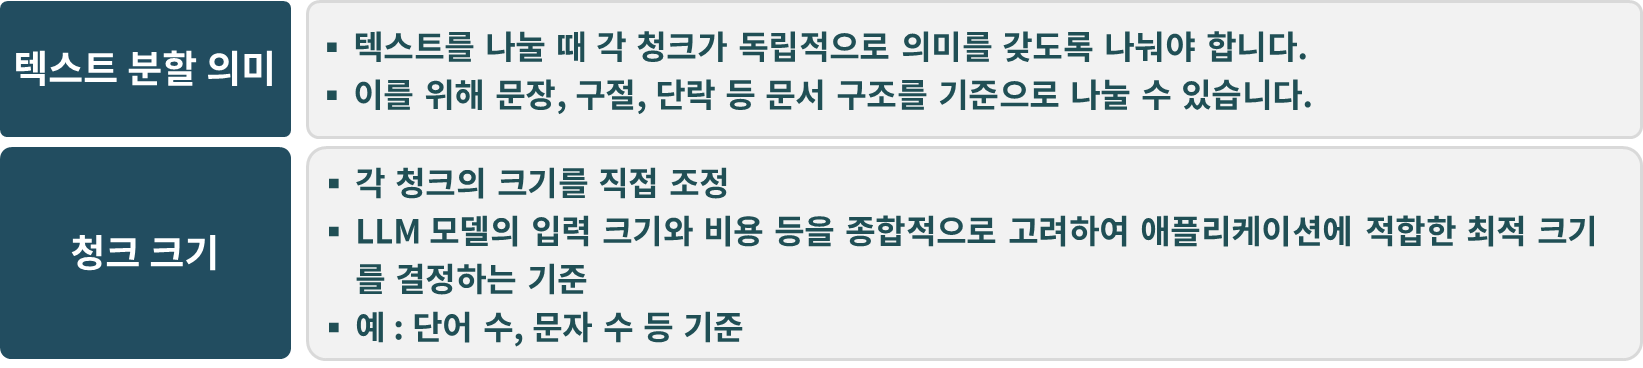

In [ ]:
from langchain.text_splitter import CharacterTextSplitter

#### 1) 글자 단위

In [ ]:
text_splitter = CharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap  = 100,
    separator = '',   # 어떤 기준 없이 무조건 500자 단위로 나누라
)

split_texts = text_splitter.split_text(text)

# 결과 확인
for i, chunk in enumerate(split_texts[:5]):  # 처음 5개 청크만 출력
    print(f"청크 {i+1}, 길이 {len(chunk)}: {chunk}\n")

#### 2) 문장 단위

In [ ]:
text_splitter = CharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    separator="."  # 문장 단위로 분할
)

split_texts = text_splitter.split_text(text)

# 결과 확인
for i, chunk in enumerate(split_texts[:5]):  # 처음 5개 청크만 출력
    print(f"청크 {i+1}, 길이 {len(chunk)}: {chunk}\n")

#### 3) 줄 바꿈 단위

In [ ]:
text_splitter = CharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap  = 100,
    separator = '\n',   # \n 줄바꿈 문자 기준으로 자르기,
)

split_texts = text_splitter.split_text(text)

# 결과 확인
for i, chunk in enumerate(split_texts[:5]):  # 처음 5개 청크만 출력
    print(f"청크 {i+1}, 길이 {len(chunk)}: {chunk}\n")

#### 4) 실습
* 다음의 옵션을 자유롭게 조절하며 청크의 크기가 어떻게 나뉘는지 살펴 봅시다.
    * chunk_size
    * chunk_overlap
    * separator

In [ ]:
text_splitter = CharacterTextSplitter(
    chunk_size = 100,
    chunk_overlap  = 50,
    separator = '',
)

split_texts = text_splitter.split_text(text)

# 결과 확인
for i, chunk in enumerate(split_texts[:5]):  # 처음 5개 청크만 출력
    print(f"청크 {i+1}, 길이 {len(chunk)}: {chunk}\n")

### (3) Embedding & Store

**임베딩(Embedding)**
- 텍스트 데이터를 숫자로 이루어진 벡터로 변환하는 과정.
- 이때, 의미적인 정보를 보존하도록 설계

**임베딩 목적**
- 벡터 표현을 사용하면, 텍스트 데이터를 벡터 공간 내에서 수학적으로 다룰 수 있게 됨
- 이를 통해 텍스트 간의 유사성을 계산 가능
- 텍스트 데이터를 기반으로 하는 다양한 머신러닝 및 자연어 처리 작업 수행

**임베딩 모델 사용**
- Openai : text-embedding-3-small

**벡터 저장소(Vector Store)**
- 벡터 형태로 표현된 데이터, 즉 임베딩 벡터들을 효율적으로 저장하고 검색할 수 있는 DB
- Vector DB라고 불림 (대표적인 Vector DB : Chroma, FAISS)

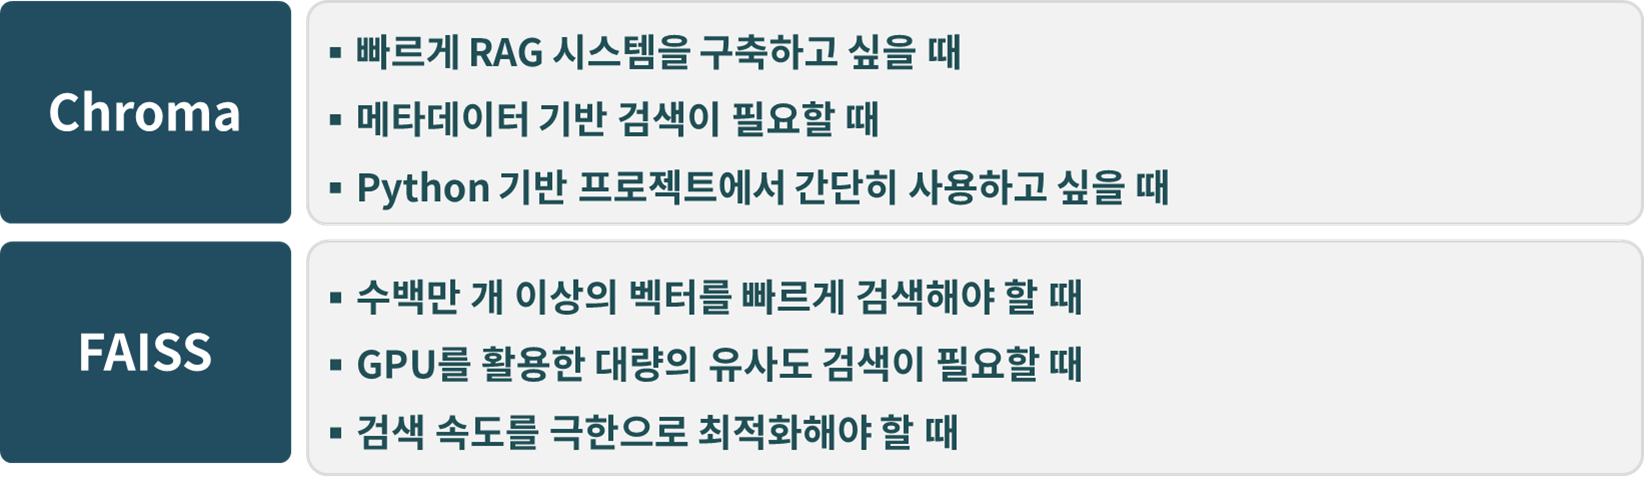



#### 1) Embedding model 선언

In [ ]:
from langchain.embeddings import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

In [ ]:
sample_text1 = "농촌 계몽운동은 한국 근대화의 중요한 과정이었다."
vector1 = embedding_model.embed_query(sample_text1)

# 벡터 길이 및 일부 값 확인
print(f"임베딩 벡터 길이: {len(vector1)}")
print(f"첫 10개 벡터 값: {vector1[:10]}")

* [참조] 두 문장이 얼마나 유사한지 코사인 유사도로 계산해 봅시다.

* ***코사인 유사도란?***
    * 수학적 의미 : 두 단위 벡터의 내적
    * NLP에서의 의미 : 유사한 벡터 -> 유사한 문맥적 의미
        * 1에 가까울수록 유사하다는 의미
        * 0이면 관계가 없다는 의미
        * -1이면 반대된다는 의미

In [ ]:
sample_text2 = "대한민국의 근대화에 농촌 개혁 운동은 큰 영향을 미쳤다."
vector2 = embedding_model.embed_query(sample_text2)

In [ ]:
from numpy.linalg import norm
# vector1, vector2 코사인 유사도 계산
def cosine_similarity(vec1, vec2):
    return float(np.dot(vec1, vec2) / (norm(vec1) * norm(vec2)))

# 두 문장의 코사인 유사도 계산
similarity_score = cosine_similarity(vector1, vector2)
similarity_score

#### 2) ChromaDB 저장

In [ ]:
# 다시 분할하자.
text_splitter = CharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap  = 100,
    separator = '\n',   # \n 줄바꿈 문자 기준으로 자르기,
)

split_texts = text_splitter.split_text(text)

In [ ]:
from langchain.vectorstores import Chroma

# ChromaDB를 만들면서 저장
vectorstore = Chroma.from_texts(split_texts, embedding_model, persist_directory="./chroma_db")

### (4) 유사도 검색

In [ ]:
query = "농촌 계몽운동에 대한 내용"
retrieved_docs = vectorstore.similarity_search(query, k=3)

# 결과 출력
print("검색 결과:")
for doc in retrieved_docs:
    print(doc.page_content)
    print('-'*200)

* 실습

몇가지 질문을 던저서 적절한 문서를 가져오는지 확인해보자

## 3.RAG 파이프라인

* 순서
    * (1) Retriever 선언
        - Vector DB에서 사용자의 질문과 가장 유사한 문서(청크)를 검색
        - 코사인 유사도(Cosine Similarity) 기반으로 유사한 문서 검색
    * (2) llm 모델 지정
        - 검색된 문서와 함께 질문을 받아 답변 생성할 LLM 모델 지정
    * (3) 메모리 선언
        - 대화의 흐름을 유지하고, 이전 질문을 기억하여 문맥을 제공
        - 프롬프트 길이를 고려한 메모리 최적화 필요        
    * (4) 체인 함수로 엮기
        - Retriever + LLM + Memory를 하나의 체인으로 연결하여 질문-응답 시스템 완성
    

### (1) RAG 파이프라인 구축

In [ ]:
# (1) 리트리버(Retriever) 생성
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 5})

# (2) GPT-4.1-mini 모델 설정
llm = ChatOpenAI(model_name="gpt-4.1-mini")

# (3) 메모리 추가 (대화 문맥 유지)
memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True, output_key="answer")

# (4) RAG 기반 ConversationalRetrievalChain 구성
qa_chain = ConversationalRetrievalChain.from_llm(
    llm=llm,
    retriever=retriever,
    memory=memory,
    return_source_documents=False  # 검색된 문서 출력 옵션
)

### (2) RAG 파이프라인 사용

In [ ]:
# 테스트 실행
query = "동혁과 영신이 하고자 했던 농촌 계몽 운동 중 가장 중요한게 뭐야?"
response = qa_chain({"question": query})

# 응답 출력
print("답변:", response["answer"])

In [ ]:
# 테스트 실행
query = "동혁과 영신은 처음 어디에서 만났어?"
response = qa_chain({"question": query})

# 응답 출력
print("답변:", response["answer"])

In [ ]:
for message in qa_chain.memory.chat_memory.messages:
    print(f"{message.type}: {message.content}")

## 4.종합실습

* 인사규정 챗봇을 만들어 봅시다.
    * 주어진 파일 "인사관리규정.txt"을 로딩
    * 적절한 크기로 split
    * chroma DB에 저장
    * RAG 구성 :
        * 요약 메모리 연결
        

In [ ]:
# 1. 텍스트 로딩


In [ ]:
# 2. 청킹


In [ ]:
# 3. 임베딩 및 Chroma에 저장


In [ ]:
# 4. 구성요소 준비

# 5. ConversationalRetrievalChain


In [ ]:
# 6. 질의
